# Environmental Impact Analysis

Analyze the carbon and water footprint impact of your diet.

In [13]:
import sys
sys.path.insert(0, '../scripts')
from load_data import load_nutrition
from carbon_footprint import load_carbon_data, load_water_data, daily_carbon, monthly_carbon, daily_water, monthly_water, carbon_by_food_type, water_by_food_type
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [14]:
nutrition = load_nutrition()
nutrition['date'] = nutrition['Date'].dt.date
carbon_data = load_carbon_data()
water_data = load_water_data()

print("Environmental impact databases loaded")
print(f"Tracking {len(carbon_data)} foods for carbon")
print(f"Tracking {len(water_data)} foods for water")

Environmental impact databases loaded
Tracking 34 foods for carbon
Tracking 34 foods for water


## Carbon Footprint

In [15]:
# Calculate daily carbon for each day
daily_carbon_list = []

for date in sorted(nutrition['date'].unique()):
    day = daily_carbon(nutrition, carbon_data, date)
    daily_carbon_list.append({
        'date': date,
        'carbon_kg': day['total_carbon_kg']
    })

daily_carbon_df = pd.DataFrame(daily_carbon_list)
daily_carbon_df.set_index('date', inplace=True)
daily_carbon_df.tail(14)

,carbon_kg
date,
2026-04-04,23.52800
2026-04-05,0.09400
2026-04-06,0.79200
2026-04-07,1.21200
2026-04-08,3.30915
2026-04-09,1.92815
2026-04-10,1.16900
2026-04-11,11.16188
2026-04-12,6.72417


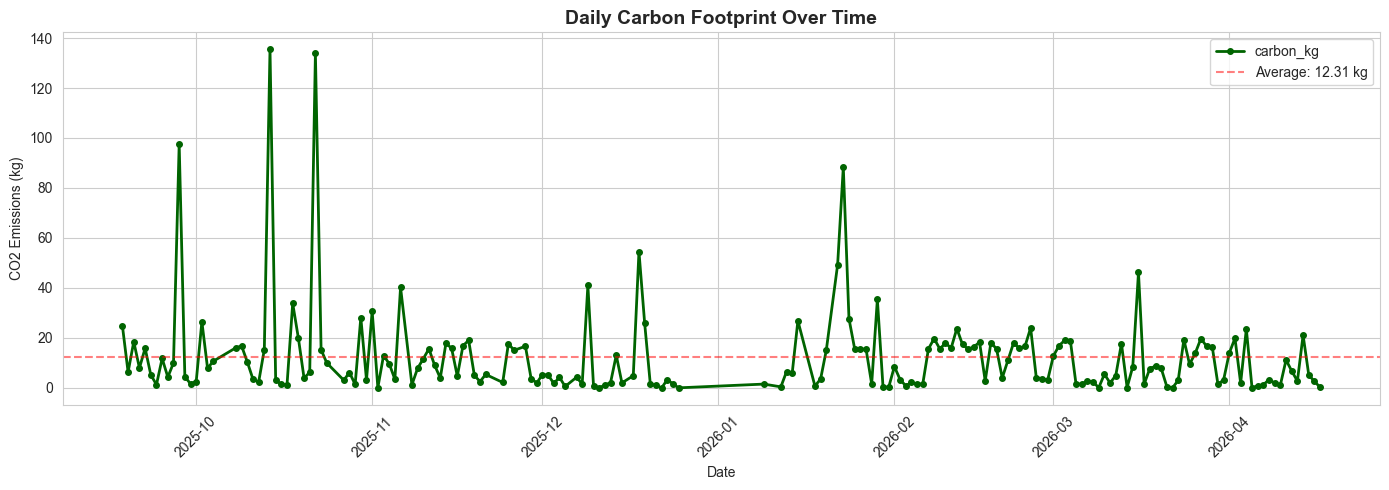

In [16]:
# Daily carbon trend
fig, ax = plt.subplots(figsize=(14, 5))
daily_carbon_df['carbon_kg'].plot(ax=ax, linewidth=2, color='darkgreen', marker='o', markersize=4)
ax.set_title('Daily Carbon Footprint Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('CO2 Emissions (kg)')
ax.axhline(y=daily_carbon_df['carbon_kg'].mean(), color='r', linestyle='--', alpha=0.5, label=f'Average: {daily_carbon_df["carbon_kg"].mean():.2f} kg')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# Monthly summary
last_30 = monthly_carbon(nutrition, carbon_data, days=30)
total_days = len(nutrition['date'].unique())
total_carbon = daily_carbon_df['carbon_kg'].sum()
avg_per_day = total_carbon / total_days if total_days > 0 else 0

print(f"Carbon Footprint - Last 30 days:")
print(f"  Total: {last_30['total_carbon_kg']:.2f} kg CO2")
print(f"  Per day: {last_30['average_per_day_kg']:.2f} kg CO2")
print(f"  Per year (extrapolated): {last_30['average_per_day_kg'] * 365:.0f} kg CO2")

print(f"\nCarbon Footprint - All Time ({total_days} days):")
print(f"  Total: {total_carbon:.2f} kg CO2")
print(f"  Per day: {avg_per_day:.2f} kg CO2")
print(f"  Per year (extrapolated): {avg_per_day * 365:.0f} kg CO2")

Carbon Footprint - Last 30 days:
  Total: 237.27 kg CO2
  Per day: 7.91 kg CO2
  Per year (extrapolated): 2887 kg CO2

Carbon Footprint - All Time (182 days):
  Total: 2239.84 kg CO2
  Per day: 12.31 kg CO2
  Per year (extrapolated): 4492 kg CO2


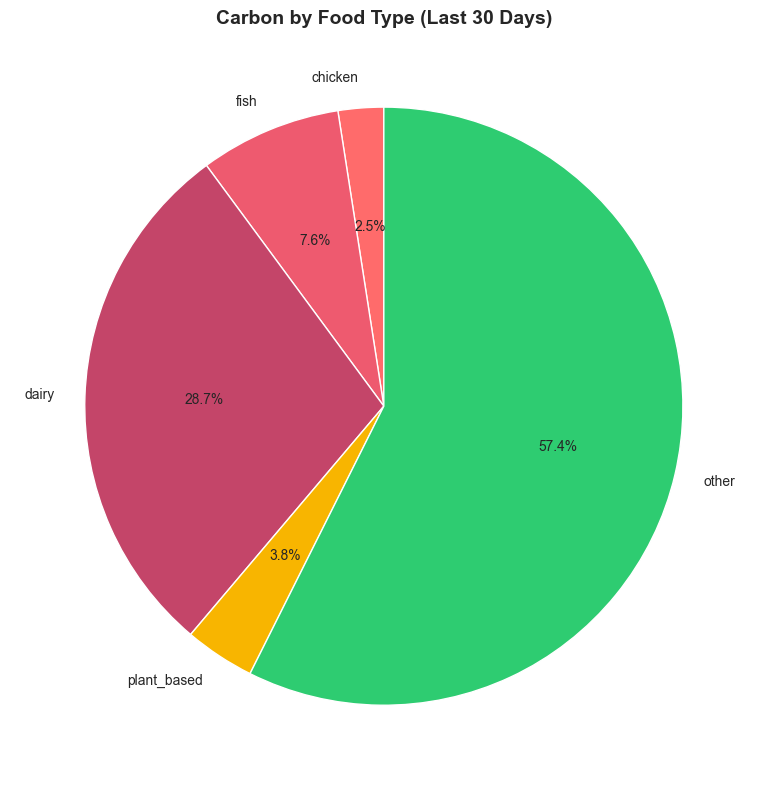

In [18]:
# Carbon by food type
cutoff = datetime.now() - timedelta(days=30)
recent = nutrition[nutrition['Date'] >= cutoff]

breakdown = carbon_by_food_type(recent, carbon_data)
breakdown_clean = {k: v for k, v in breakdown.items() if v > 0}

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#ff6b6b', '#ee5a6f', '#c44569', '#f8b500', '#2ecc71', '#3498db', '#95a5a6']
ax.pie(breakdown_clean.values(), labels=breakdown_clean.keys(), autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Carbon by Food Type (Last 30 Days)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Water Footprint

In [19]:
# Calculate daily water for each day
daily_water_list = []

for date in sorted(nutrition['date'].unique()):
    day = daily_water(nutrition, water_data, date)
    daily_water_list.append({
        'date': date,
        'water_liters': day['total_water_liters']
    })

daily_water_df = pd.DataFrame(daily_water_list)
daily_water_df.set_index('date', inplace=True)
daily_water_df.tail(14)

,water_liters
date,
2026-04-04,150.02000
2026-04-05,0.45800
2026-04-06,31.58400
2026-04-07,8.65200
2026-04-08,29.94770
2026-04-09,76.53370
2026-04-10,67.11740
2026-04-11,77.33064
2026-04-12,67.43780


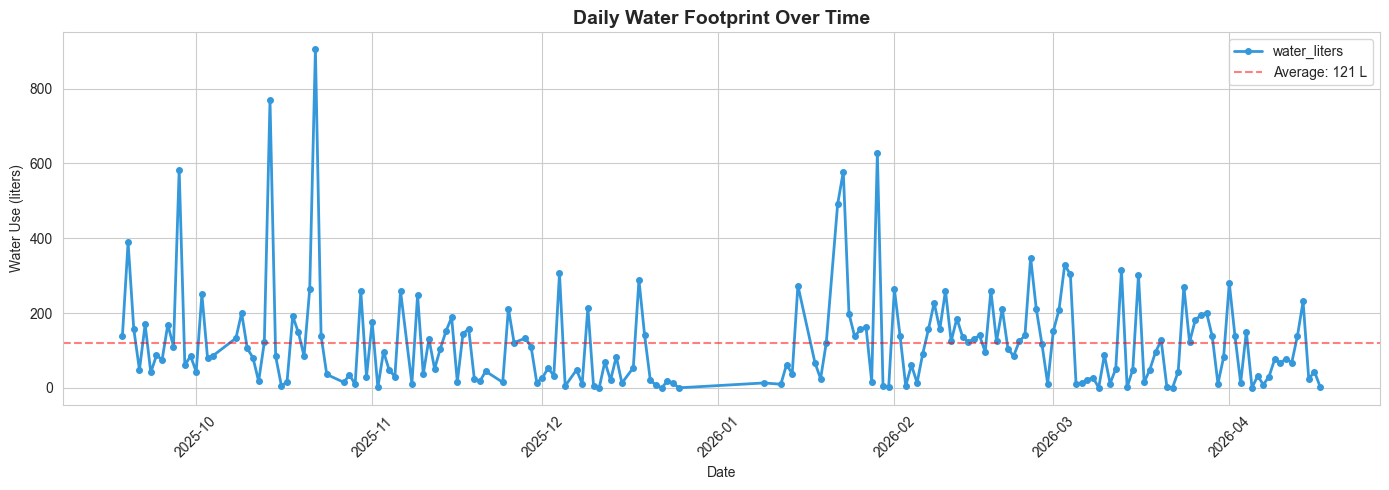

In [20]:
# Daily water trend
fig, ax = plt.subplots(figsize=(14, 5))
daily_water_df['water_liters'].plot(ax=ax, linewidth=2, color='#3498db', marker='o', markersize=4)
ax.set_title('Daily Water Footprint Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Water Use (liters)')
ax.axhline(y=daily_water_df['water_liters'].mean(), color='r', linestyle='--', alpha=0.5, label=f'Average: {daily_water_df["water_liters"].mean():.0f} L')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
# Monthly summary
last_30_water = monthly_water(nutrition, water_data, days=30)
total_water = daily_water_df['water_liters'].sum()
avg_water_per_day = total_water / total_days if total_days > 0 else 0

print(f"Water Footprint - Last 30 days:")
print(f"  Total: {last_30_water['total_water_liters']:,.0f} liters")
print(f"  Per day: {last_30_water['average_per_day_liters']:,.0f} liters")
print(f"  Per year (extrapolated): {last_30_water['average_per_day_liters'] * 365:,.0f} liters")

print(f"\nWater Footprint - All Time ({total_days} days):")
print(f"  Total: {total_water:,.0f} liters")
print(f"  Per day: {avg_water_per_day:,.0f} liters")
print(f"  Per year (extrapolated): {avg_water_per_day * 365:,.0f} liters")

Water Footprint - Last 30 days:
  Total: 2,847 liters
  Per day: 95 liters
  Per year (extrapolated): 34,644 liters

Water Footprint - All Time (182 days):
  Total: 22,007 liters
  Per day: 121 liters
  Per year (extrapolated): 44,136 liters


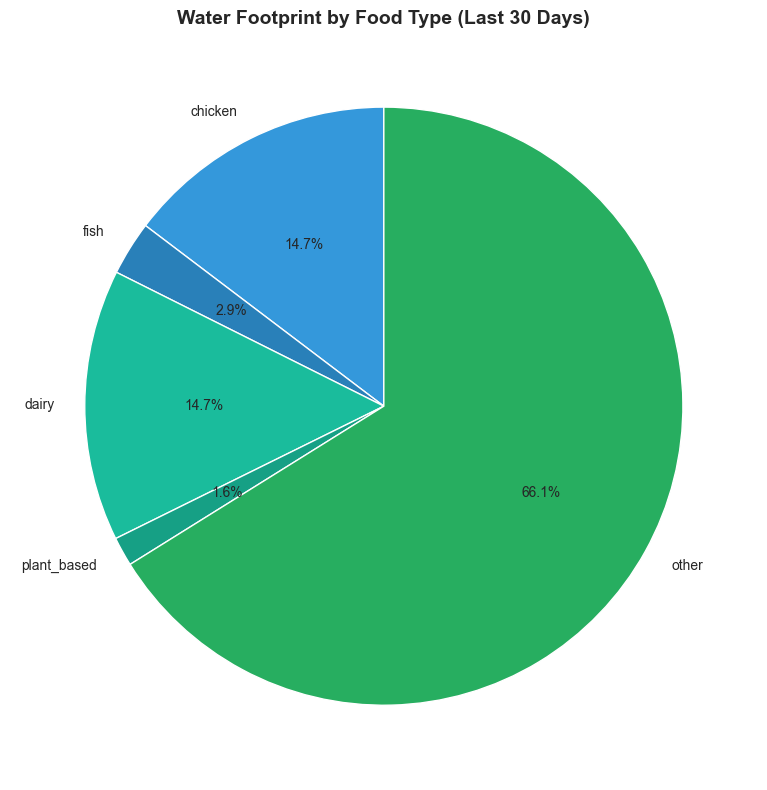

In [22]:
# Water by food type
water_breakdown = water_by_food_type(recent, water_data)
water_breakdown_clean = {k: v for k, v in water_breakdown.items() if v > 0}

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#3498db', '#2980b9', '#1abc9c', '#16a085', '#27ae60', '#2ecc71', '#95a5a6']
ax.pie(water_breakdown_clean.values(), labels=water_breakdown_clean.keys(), autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Water Footprint by Food Type (Last 30 Days)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()